<style>a{text-decoration:none !important}</style>
# Transformer Implementation (cross attention)

In this notebook, we will implement the Transformer architecture on a french-english translation problem.\
Starting point: https://nlp.seas.harvard.edu/annotated-transformer/. I have added mHC, RoPE, RMSNorm and soon Engram.


$$ \text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V $$

We write our dimensions as such:
- B the batch dimension (amount of sentences)
- L the sentence length (amount of tokens per sentence)
- D the feature dimension (amount of details per token)
- S the amount of streams (versions of the same token)
- H the amount of heads (amount of tuples Q,K,V)
- V the vocabulary size (the lenght of the tokenizer)

Our tensors flowing through the hidden states will be of shape (B, L, S, D). Before entering the network, they will be of size (B, L, D), then cloned into S streams, and at the end the streams will be averaged to return to (B, L, D) to compute probabilities for each word of V.


Planned features: MoE, SwiGLU, Sparse and Flash attention, Engram

We add an engram layer in the second bloc of the encoder and decoder. It shouldn't be added inside the first blocs, the model doesnt have enougn time ot understand context and the gating of memory would be bad. 


In [186]:
import copy
import time
import math
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader

In [187]:
DATA_PATH = "kaggle/input/wmt-2014-english-french/wmt14_translate_fr-en_train.csv"
DEVICE = "mps"

CONFIG = {
    "batch_size": 16,
    "feature_amount": 512, # how precise our tokens are
    "vocab_size": 32000,  # amount of distinct chunks of words
    "dataset_lenght": 1000,  # lines of the CSV dataset
    "head_amount": 8, # each head is a question/answer space
    "stream_amount": 4, # amount of evil twins for each token
    "num_epochs": 3,
    "accum_iter": 10,  # amount of batches computed to increment the weights (effective batch = iter*batch_size)
    "base_lr": 1.0,  # learning rate
    "max_padding": 72, # length of sentences, filled with paddings to reach it
    "warmup": 3000  # linear increase of the learning rate
}

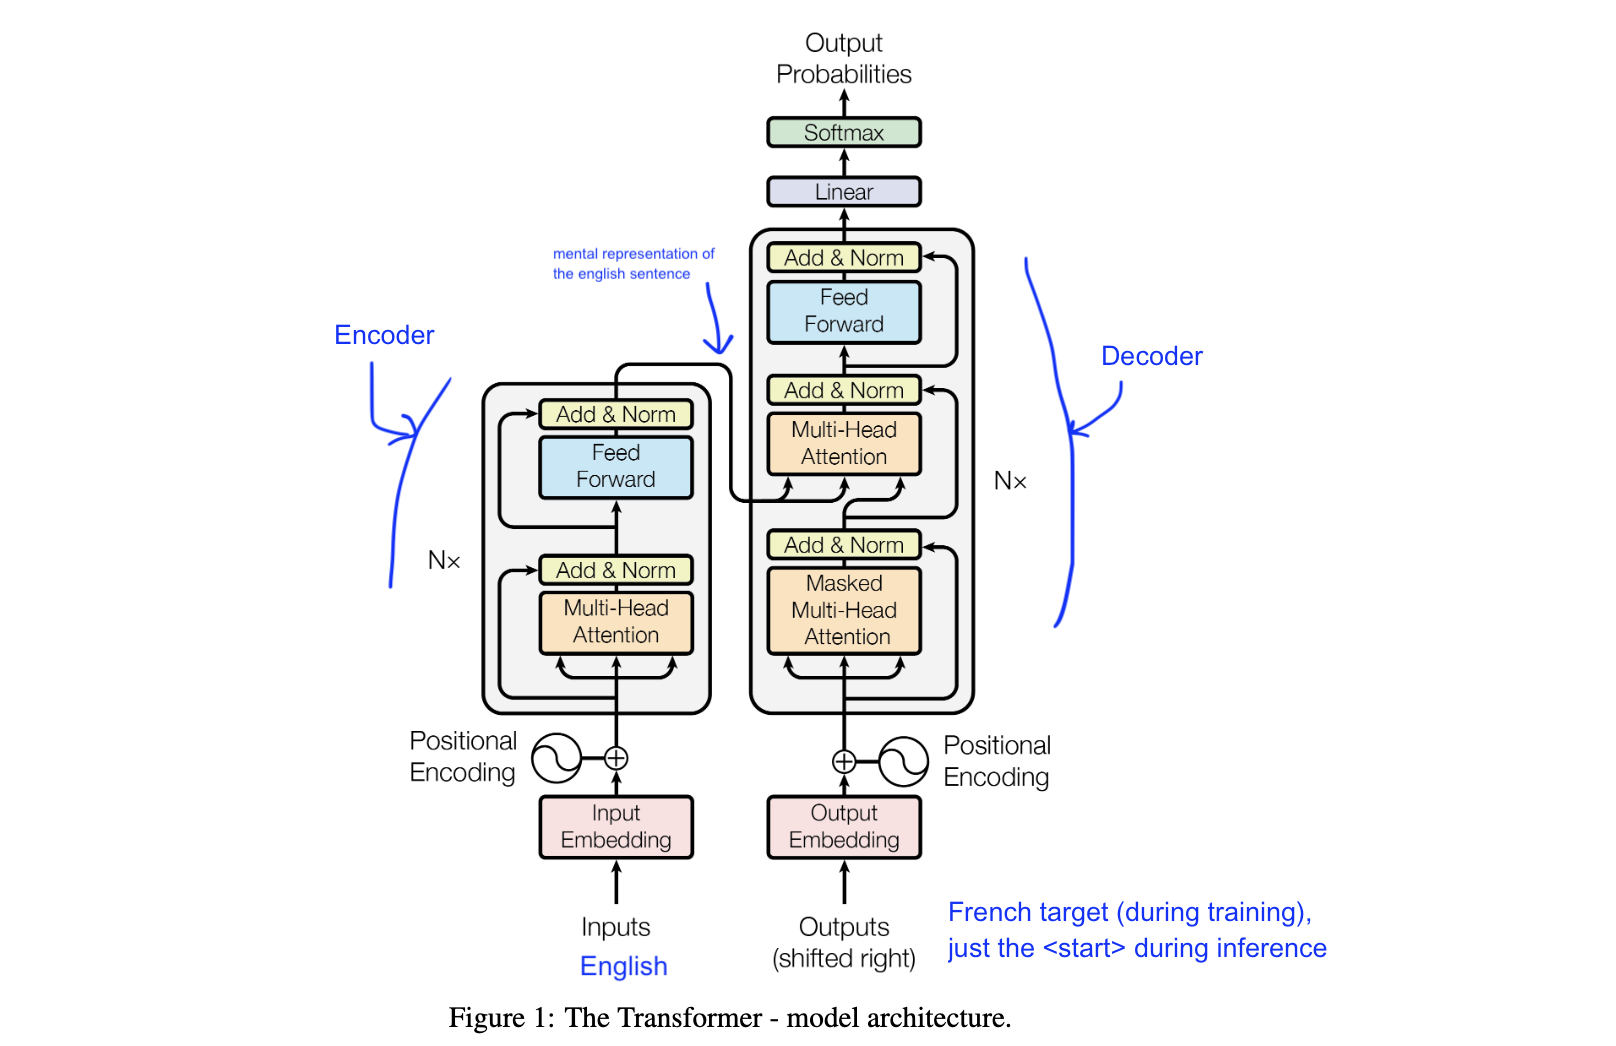

In [188]:
class EncoderDecoder(nn.Module):
    "the whole architecture."

    def __init__(self, encoder, decoder, src_embed, tgt_embed, generator):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed = src_embed # first layer that turns a sentence into tokens + positions encoding
        self.tgt_embed = tgt_embed
        self.generator = generator # final layer that turns decoder outputs into probabilities

    def forward(self, src, tgt, src_mask, tgt_mask):
        # src: (B, L), tgt: (B, L-1)
        # src_mask: (B, 1, L), to hide <pad>
        # tgt_mask: (B, 1, L-1, L-1), to hide <pad> and future tokens
        return self.decode(self.encode(src, src_mask), src_mask, tgt, tgt_mask)

    def encode(self, src, src_mask):
        x = self.src_embed(src) # x: (B, L, D)
        B, L, D = x.shape
        S = self.encoder.stream_amount
        x = x.unsqueeze(2).expand(B, L, S, D) # x: (B, L, S, D)
        return self.encoder(x, src_mask) # mask is meant to hide the <pad>

    def decode(self, representation, src_mask, tgt, tgt_mask):
        # representation: (B, L, S*D)
        B, L, SD = representation.shape
        S = self.decoder.stream_amount
        
        representation = representation.view(B, L, S, SD // S) # representation: (B, L, S, D)
        representation = representation.mean(dim=2) # average over streams 
        representation = representation.unsqueeze(2) # representation: (B, L, 1, D)

        x = self.tgt_embed(tgt)
        x = x.unsqueeze(2).expand(B, x.size(1), S, SD // S) # x: (B, L, S, D)
        return self.decoder(x, representation, src_mask, tgt_mask)

In [189]:
def xavier_init(module):
    "Helper to initialize weights with Xavier uniform, ignoring biaises and scalars."
    for p in module.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)

In [190]:
class Generator(nn.Module):
    "Final layer that turns the logits into probabilities. Predict the next word."

    def __init__(self, feature_amount, vocab):
        super().__init__()
        self.proj = nn.Linear(feature_amount, vocab)
        xavier_init(self)

    def forward(self, x):
        # x: (B, L, D)
        # output: (B, L, V)
        probability = F.log_softmax(self.proj(x), dim=-1)
        return probability

In [191]:
def clones(module, N):
    "Helper to produce N identical layers."
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])

In [192]:
class Encoder(nn.Module):
    """
    Encoder is a stack of N layers, each layer containing a multi-head 
    self-attention sublayer, a feed-forward sublayer, connected by mHconnections. 
    """

    def __init__(self, layer, N, stream_amount=4):
        super().__init__()
        river_size = layer.feature_amount*stream_amount
        self.layers = clones(layer, N)
        self.norm = RMSNorm(river_size)
        self.stream_amount = stream_amount

    def forward(self, x, mask):
        # x: (B, L, S, D)
        # mask: (B, 1, L)
        "Pass the input through each layer sequentially."
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x.flatten(start_dim=2).contiguous()) # x: (B, L, S*D)

In [193]:
class RMSNorm(nn.Module):
    "Only scale by root mean square. Computationaly more efficient. Doesn't hurt performance."

    def __init__(self, river_size, eps=1e-6):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(river_size))
        self.eps = eps

    def forward(self, x):
        # x: (B, L, S*D)
        rms = torch.sqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
        return self.scale * (x / rms)
               

In [194]:
def make_doubly_stochastic(matrix, iterations=5): # Sinkhorn-Knopp algorithm for mHC
    M = torch.exp(matrix)  # ensures positivity
    for i in range(iterations): # alternate row and column normalization
        M = M / M.sum(dim=-1, keepdim=True)
        M = M / M.sum(dim=-2, keepdim=True)   
    return M  

In [195]:
class mHConnection(nn.Module):
    """
    The newest Deepseek implementation of the mHC, replacing residual connection.
    Implement three matrices, mixing streams after every layer.
    """

    def __init__(self, stream_amount, feature_amount, dropout_rate=0.1):
        super().__init__()
        river_size = stream_amount*feature_amount
        self.river_size = river_size
        self.norm = RMSNorm(river_size)
        self.dropout = nn.Dropout(dropout_rate) 
        
        self.alpha_pre = nn.Parameter(torch.tensor(0.01))
        self.alpha_post = nn.Parameter(torch.tensor(0.01))
        self.alpha_res = nn.Parameter(torch.tensor(0.01))
        
        self.phi_pre = nn.Parameter(torch.empty(river_size, stream_amount))
        self.phi_post = nn.Parameter(torch.empty(river_size, stream_amount))
        self.phi_res = nn.Parameter(torch.empty(river_size, stream_amount, stream_amount))
        xavier_init(self)

        self.biais_pre = nn.Parameter(torch.zeros(stream_amount))
        self.biais_post = nn.Parameter(torch.zeros(stream_amount))
        self.biais_res = nn.Parameter(torch.eye(stream_amount) * 5) # bias: (S, S)
        # 5 is the default value in the Deepseek paper
        
    def forward(self, x, sublayer):
        # x: (B, L, S, D)
        B, L, S, D = x.shape
        x_river = x.flatten(start_dim=2) # shape: (B, L, S*D)
        x_river = self.norm(x_river) # normalize over all versions of the token

        H_pre = self.alpha_pre * x_river@self.phi_pre + self.biais_pre
        H_post = self.alpha_post * x_river@self.phi_post + self.biais_post
        H_res = self.alpha_res * torch.einsum('bld,dst->blst', x_river, self.phi_res) + self.biais_res

        H_pre = F.sigmoid(H_pre).unsqueeze(2) # shape: (B, L, 1, S)
        H_post = 2*F.sigmoid(H_post).unsqueeze(3) # shape: (B, L, S, 1)
        H_res = make_doubly_stochastic(H_res) # shape: (B, L, S, S)
        
        # sublayer: (B, L, 1, D) -> (B, L, 1, D)
        x_norm = x_river.view(B, L, S, D)
        return H_res@x + H_post@self.dropout(sublayer(H_pre@x_norm))

In [196]:
class EncoderLayer(nn.Module):
    "Encoder is made up of self-attention and feed forward"
    def __init__(self, feature_amount, stream_amount, self_attn, feed_forward, dropout_rate):
        super().__init__()
        self.self_attn = self_attn
        self.feed_forward = feed_forward
        self.sublayer = clones(mHConnection(stream_amount, feature_amount, dropout_rate), 2)
        self.feature_amount = feature_amount

    def forward(self, x, mask):
        # x: (B, L, S, D)
        # mask: (B, 1, L)
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, mask)) # attention
        x = self.sublayer[1](x, self.feed_forward)  # feed forward
        return x

In [ ]:
class Decoder(nn.Module):
    "Generic N layer decoder with masking."

    def __init__(self, layer, N, stream_amount=CONFIG["stream_amount"]):
        super().__init__()
        river_size = stream_amount*layer.feature_amount
        self.layers = clones(layer, N)
        self.norm = RMSNorm(river_size)
        self.stream_amount = stream_amount

    def forward(self, x, memory, src_mask, tgt_mask):
        # x: (B, L, S, D)
        # memory: (B, L, S, D)
        # src_mask: (B, 1, L)
        # tgt_mask: (B, 1, L, L)
        for layer in self.layers:
            x = layer(x, memory, src_mask, tgt_mask)
        
        x = self.norm(x.flatten(start_dim=2).contiguous()) # x: (B, L, S*D)
        B, L, SD = x.shape
        S = self.stream_amount
        x = x.view(B, L, S, SD // S).mean(dim=2) # x: (B, L, D)
        return x

In [ ]:
class DecoderLayer(nn.Module):
    "Decoder is made of 3 layers: self-attention, source-attention, and feed forward."
    def __init__(self, feature_amount, stream_amount, self_attn, src_attn, feed_forward, engram, dropout_rate=0.1):
        super().__init__()
        self.self_attn = self_attn
        self.src_attn = src_attn
        self.feed_forward = feed_forward
        self.engram = engram
        self.sublayer = clones(mHConnection(stream_amount, feature_amount, dropout_rate), 3)
        self.feature_amount = feature_amount

    def forward(self, x, memory, src_mask, tgt_mask):
        # x: (B, L, S, D)
        # memory: (B, L_src, S, D)
        # src_mask: (B, 1, L_src)
        # tgt_mask: (B, 1, L, L)
        # output: (B, L, S, D)
        m = memory
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, tgt_mask))
        x = self.sublayer[1](x, lambda x: self.src_attn(x, m, m, src_mask))
        x = self.sublayer[2](x, self.feed_forward)
        return x

In [199]:
def subsequent_mask(sentence_length):
    "Mask out subsequent positions."
    attn_shape = (1, sentence_length, sentence_length)
    subsequent_mask = torch.triu(torch.ones(attn_shape), diagonal=1)
    # zeros everything under the first line above the diagonal of the matrix
    mask = (subsequent_mask == 0) # True/False instead of 0/1
    return mask

In [200]:
def attention(query, key, value, mask=None, dropout=None):
    "Scaled dot product between query and key, and distribute the scores on value."

    d_k = query.size(-1)  # query/key smaller head_dimension (divider of feature_amount)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)
    # divide by sqrt(d_k) to not reach softmax plateau where gradient is almost zero

    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
        
    p_attn = scores.softmax(dim=-1) # probability of key answering query
    if dropout is not None:
        p_attn = dropout(p_attn)

    return torch.matmul(p_attn, value), p_attn

In [201]:
class MultiHeadedAttention(nn.Module):
    """
    Multi-head attention module: projects into smaller dimension spaces 
    and then apply specialized attention in each of them.
    """

    def __init__(self, head_amount, feature_amount, max_padding=72, dropout_rate=0.1):
        super().__init__()
        self.head_dimension = feature_amount // head_amount # feature_amount = head_amount * head_dimension
        self.head_amount = head_amount
        self.linears = clones(nn.Linear(feature_amount, feature_amount, bias=False), 4) # Q, K, V, Out 
        self.attn = None
        self.dropout = nn.Dropout(dropout_rate)

        cos, sin = frequencies(self.head_dimension, max_padding)
        self.register_buffer("sin", sin) # to move them on DEVICE with the instance
        self.register_buffer("cos", cos)
        xavier_init(self)

    def forward(self, query, key, value, mask=None):
        # query, key, value: (B, L, 1, D)
        # mask: (B, 1, L)
        B, L, _, D = query.size()

        if mask is not None:
            mask = mask.unsqueeze(1) # mask: (B, 1, 1, L)
            
        # MPS FIX: Ensure 3D input for Linear layers (B, L, D) instead of (B, L, 1, D)
        query = query.view(B, -1, D)
        key = key.view(B, -1, D)
        value = value.view(B, -1, D)

        query, key, value = [
            lin(x).view(B, -1, self.head_amount, self.head_dimension).transpose(1, 2)
            for lin, x in zip(self.linears, (query, key, value))
        ] # q, k, v: (B, H, L, D/H)
        # we use -1 instead of L because it can be either L or L-1

        query = embed_positions(query, self.cos, self.sin)
        key = embed_positions(key, self.cos, self.sin)
        x, self.attn = attention(query, key, value, mask=mask, dropout=self.dropout)
        
        # MPS FIX: Flatten to 3D for final linear layer (B, L, D)
        x = x.transpose(1, 2).reshape(B, L, self.head_amount * self.head_dimension)
        
        return self.linears[3](x).unsqueeze(2) # apply final linear projection and restore 4D

In [202]:
def frequencies(feature_amount, max_padding, theta = 1000):
    """Precompute the frequencies for all token positions in the sentence and
    for all pairs of features."""
    freqs = 1.0 / (theta ** (torch.arange(0, feature_amount, 2) / feature_amount))
    # the first feature pairs  have high frequency, hence distance sensitive, the final pairs have low frequencies and are capture global properties
    t = torch.arange(max_padding)
    freqs = torch.outer(t, freqs).float() # all possible products
    return torch.cos(freqs), torch.sin(freqs)

def embed_positions(A, cos, sin):
    """Apply the rotation to q and k to embed token relative positions."""
    cos, sin = (x[:A.size(-2)].to(A)[None, None].repeat_interleave(2, dim=-1) for x in (cos, sin))
    x1, x2 = A.chunk(2, dim=-1)
    return A * cos + torch.cat((-x2, x1), dim=-1) * sin

In [203]:
class PositionwiseFeedForward(nn.Module):
    "Implements FFN bloc, composed of 2 fully connected layers"

    def __init__(self, feature_amount, d_ff, dropout_rate=0.1):
        super().__init__()
        self.w_1 = nn.Linear(feature_amount, d_ff) # d_ff is usually 4 times feature_amount
        self.w_2 = nn.Linear(d_ff, feature_amount)
        self.dropout = nn.Dropout(dropout_rate)
        xavier_init(self)

    def forward(self, x):
        # x: (B, L, 1, D)
        x = self.w_1(x)
        x = x.relu()
        x = self.dropout(x)
        x = self.w_2(x)
        return x

In [204]:
class SimpleLossCompute:
    "Compute loss."

    def __init__(self, generator, criterion):
        self.generator = generator 
        self.criterion = criterion # the loss

    def __call__(self, x, y, norm):
        # norm is amounf of tokens (excluding paddings)
        x = self.generator(x)
        loss = (
            self.criterion(x.reshape(-1, x.size(-1)), y.reshape(-1))
            / norm  # average loss per token
        )
        return loss.data * norm, loss 
        # we return the unscaled loss too to reaverage over an epoch later on

In [ ]:
def make_model(src_vocab, tgt_vocab, stream_amount=CONFIG["stream_amount"], 
               N=2, feature_amount=CONFIG["feature_amount"], d_ff=2048, h=CONFIG["head_amount"], 
               max_padding=CONFIG["max_padding"], dropout_rate=0.1):
    "Construct an instance of the model from hyperparameters."

    river_size = feature_amount*stream_amount
    c = copy.deepcopy # makes an instance out of an instance, basically "classifying" an instance
    attn = MultiHeadedAttention(h, feature_amount, max_padding, dropout_rate)
    ff = PositionwiseFeedForward(feature_amount, d_ff, dropout_rate)
    engram = Engram(feature_amount, dropout_rate)

    model = EncoderDecoder(
        Encoder(EncoderLayer(feature_amount, stream_amount, c(attn), c(ff), c(engram), dropout_rate), N),
        Decoder(DecoderLayer(feature_amount, stream_amount, c(attn), c(attn), c(ff), c(engram), dropout_rate), N),
        nn.Sequential(Embeddings(feature_amount, src_vocab)),
        nn.Sequential(Embeddings(feature_amount, tgt_vocab)),
        Generator(feature_amount, tgt_vocab),
    )

    return model

In [206]:
class Batch:
    "Object for holding a batch of data with mask during training."
    def __init__(self, src, tgt=None, pad=2):  # 2 = <blank>
        self.src = src
        self.src_mask = (src != pad).unsqueeze(-2)
        if tgt is not None:
            self.tgt = tgt[:, :-1]
            self.tgt_y = tgt[:, 1:]
            self.tgt_mask = self.make_std_mask(self.tgt, pad)
            self.ntokens = (self.tgt_y != pad).data.sum()

    @staticmethod
    def make_std_mask(tgt, pad):
        "Create a mask to hide padding and future words."
        tgt_mask = (tgt != pad).unsqueeze(-2)
        tgt_mask = tgt_mask & subsequent_mask(tgt.size(-1)).type_as(tgt_mask.data)
        return tgt_mask

In [207]:
def rate(step, model_size, factor, warmup):
    "Adaptive step rate, linear warmup, then square root decay"
    if step == 0:
        step = 1
    rate = factor * (model_size ** (-0.5) * min(step ** (-0.5), step * warmup ** (-1.5)))
    return rate

In [ ]:
class LabelSmoothing(nn.Module):
    """
    Implement label smoothing. Prevent trying to reach P = 1 or 0 
    and overfit. Increase perplexity, but improve BLEU score.
    """

    def __init__(self, feature_amount, padding_idx, smoothing=0.0):
        super().__init__()
        self.criterion = nn.KLDivLoss(reduction="sum")
        self.padding_idx = padding_idx
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.feature_amount = feature_amount
        self.true_dist = None

    def forward(self, x, target):
        assert x.size(1) == self.feature_amount
        true_dist = x.data.clone()
        true_dist.fill_(self.smoothing / (self.feature_amount - 2))
        true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        true_dist[:, self.padding_idx] = 0
        mask = torch.nonzero(target.data == self.padding_idx)
        if mask.dim() > 0:
            true_dist.index_fill_(0, mask.squeeze(), 0.0)
        self.true_dist = true_dist
        return self.criterion(x, true_dist.clone().detach())

In [ ]:
def hash(head_number, engram):
    "k-th deterministic multiplicative-XOR hash."
    if engram.dim() == 0:
        return ((engram * (6364136223846793005 + head_number)) ^ 1469598103934665603) & 0x7FFFFFFFFFFFFFFF
    if engram.dim() == 1:
        engram = engram.unsqueeze(-1)
    h = torch.full(engram.shape[:-1], 1469598103934665603 + head_number, dtype=torch.int64, device=engram.device)
    for i in range(engram.size(-1)):
        h = (h * 6364136223846793005) ^ (engram[..., i] + i + 1)
    return h & 0x7FFFFFFFFFFFFFFF

In [ ]:
class Engram(nn.Module):
    """
    Engram layer, with k-head hashing of the n-lenght engram at position t.
    This stores memory of the model, and offset other layers to focus on reasoning.
    """
    def __init__(self, feature_amount, dropout_rate, head_amount):
        super().__init__()


# Tokenizing and embedding

In [209]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Metaspace
from tokenizers.processors import TemplateProcessing
from tokenizers.decoders import Metaspace as MetaspaceDecoder

In [210]:
def load_data(data_path=DATA_PATH):
    df = pd.read_csv(
        data_path, 
        engine='python',        # Robust parser
        on_bad_lines='skip',
        nrows=CONFIG['dataset_lenght']
    )    
    
    def clean(text):
        if not isinstance(text, str): return text
        replacements = {
            "Ã©": "é", 
            "Ã¨": "è", 
            "Ã ": "à", 
            "Ã ": "à", 
            "Ã´": "ô", 
            "Ã»": "û", 
            "Ã¯": "ï",
            "Ã¹": "ù", 
            "Ãî": "î", 
            "Ã‰": "É", 
            "Â ": " ",      
            "â–": "_",  
            "Â»": "»", 
            "Â«": "«",  
            "Ã§": "ç",
            "Ã®": "î",
            "Ãª": "ê",
            "Ã€": "À",
            "Ã‡": "Ç"
        }
        for bad, good in replacements.items():
            text = text.replace(bad, good)
        return text

    df['fr'] = df['fr'].apply(clean)
    df['en'] = df['en'].apply(clean)
    
    train_src = df['fr'].tolist() # Source is French
    train_tgt = df['en'].tolist() # Target is English
    return train_src, train_tgt

In [211]:
def train_tokenizer(data, vocab_size, min_frequency=2):
    "Construct a tokenizer using Byte-Pair Encoding"

    tokenizer = Tokenizer(BPE(unk_token="<unk>"))
    tokenizer.pre_tokenizer = Metaspace(replacement="_") # use _ for spaces
    trainer = BpeTrainer(special_tokens=["<s>", "<pad>", "</s>", "<unk>"], 
                         vocab_size=vocab_size, 
                         min_frequency=min_frequency)
    tokenizer.train_from_iterator(data, trainer)
    
    # post-processing: add <s> at start and end
    tokenizer.post_processor = TemplateProcessing(
        single="<s> $A </s>",
        pair="<s> $A </s> $B:1 </s>:1",
        special_tokens=[
            ("<s>", tokenizer.token_to_id("<s>")),
            ("</s>", tokenizer.token_to_id("</s>")),
        ],
    )
    tokenizer.decoder = MetaspaceDecoder(replacement="_")
    return tokenizer

In [212]:
def load_tokenizers(data_path=DATA_PATH):
    "Read the csv and returns two JSON containing the tokenizers"
    train_src, train_tgt = load_data(data_path=DATA_PATH)
    tokenizer_src = train_tokenizer(train_src, vocab_size=CONFIG['vocab_size'])
    tokenizer_tgt = train_tokenizer(train_tgt, vocab_size=CONFIG['vocab_size'])
    tokenizer_src.save("tokenizers/tokenizer_src.json")
    tokenizer_tgt.save("tokenizers/tokenizer_tgt.json")
    return tokenizer_src, tokenizer_tgt

In [213]:
class Embeddings(nn.Module):
    def __init__(self, feature_amount, vocab):
        super().__init__()
        self.embedding_table = nn.Embedding(vocab, feature_amount)
        self.feature_amount = feature_amount
        xavier_init(self)

    def forward(self, x):
        # x: (B, L) (indices)
        # output: (B, L, S, d)
        return self.embedding_table(x) * math.sqrt(self.feature_amount)

# Training

In [ ]:
def run_epoch(data_iter, model, loss_compute, optimizer=None, scheduler=None, mode="train",
    accum_iter=1):
    "Runs one epoch, either for training, either validation."
    
    start = time.time()
    total_tokens, total_loss, tokens, n_accum = 0, 0, 0, 0
    loss_list, grad_norms = [], []

    for i, batch in enumerate(data_iter):
        out = model.forward(batch.src, batch.tgt, batch.src_mask, batch.tgt_mask)
        loss, loss_node = loss_compute(out, batch.tgt_y, batch.ntokens)

        if mode == "train":
            (loss_node / accum_iter).backward()
            if i % accum_iter == 0:
                if optimizer is not None:
                    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), float('inf'))
                    grad_norms.append(norm.item())
                    optimizer.step()
                    optimizer.zero_grad(set_to_none=True)
                n_accum += 1
            if scheduler is not None:
                scheduler.step()

        total_loss += loss
        total_tokens += batch.ntokens
        tokens += batch.ntokens
        loss_list.append((loss / batch.ntokens).item())

        if i % 40 == 1 and (mode == "train"): # print every 40 batches
            lr = optimizer.param_groups[0]["lr"]
            elapsed = time.time() - start
            print(
                ("Epoch: %6d | Accum. Step: %3d | Loss: %6.2f " + "| Tokens/sec: %7.1f | Learn. Rate: %6.1e")
                % (i, n_accum, loss / batch.ntokens, tokens / elapsed, lr)
            )
            start = time.time()
            tokens = 0

    return loss_list, grad_norms

In [215]:
def collate_batch(batch, src_tokenizer, tgt_tokenizer, max_padding=CONFIG["max_padding"], pad_id=1):
    "Makes every sentence have the same lenght of max_padding to get a tensor"
    src_list, tgt_list = [], []
    
    for (sentence_src, sentence_tgt) in batch:
        encoded_src = src_tokenizer.encode(sentence_src).ids
        encoded_tgt = tgt_tokenizer.encode(sentence_tgt).ids
        src_tensor = torch.tensor(encoded_src, dtype=torch.int64, device=DEVICE)
        tgt_tensor = torch.tensor(encoded_tgt, dtype=torch.int64, device=DEVICE)

        # pad to reach max length
        src_list.append(F.pad(src_tensor, (0, max_padding - len(src_tensor)), value=pad_id))
        tgt_list.append(F.pad(tgt_tensor, (0, max_padding - len(tgt_tensor)), value=pad_id))

    src = torch.stack(src_list)
    tgt = torch.stack(tgt_list)
    return (src, tgt)

In [216]:
def create_dataloaders(vocab_src, vocab_tgt, batch_size=12000, max_padding=CONFIG["max_padding"]):
    "Instantiate the dataloaders for training and validation."
  
    pad_id = vocab_src.token_to_id("<pad>") # get pad ID dynamically
    def collate_fn(batch):
        return collate_batch(
            batch,
            vocab_src,
            vocab_tgt,
            max_padding=max_padding,
            pad_id=pad_id,
        )

    train_src, train_tgt = load_data(DATA_PATH)
    split_idx = int(len(train_src) * 0.95)
    train_iter = list(zip(train_src[:split_idx], train_tgt[:split_idx]))
    valid_iter = list(zip(train_src[split_idx:], train_tgt[split_idx:]))

    train_dataloader = DataLoader(
        train_iter,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn,
    )
    valid_dataloader = DataLoader(
        valid_iter,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
    )
    return train_dataloader, valid_dataloader

In [217]:
def train_model(tokenizer_src, tokenizer_tgt):
    " Launch the training process of a model"
    print("Training process starting...", flush=True)
    
    pad_idx = tokenizer_tgt.token_to_id("<pad>")
    model = make_model(tokenizer_src.get_vocab_size(), tokenizer_tgt.get_vocab_size())
    device = torch.device(DEVICE)
    model.to(device)
    model_param_count = sum(p.numel() for p in model.parameters())
    
    criterion = LabelSmoothing(feature_amount=tokenizer_tgt.get_vocab_size(), padding_idx=pad_idx, smoothing=0.1)
    criterion.to(device)

    train_dataloader, valid_dataloader = create_dataloaders(
        tokenizer_src,
        tokenizer_tgt,
        batch_size=CONFIG["batch_size"],
        max_padding=CONFIG["max_padding"])

    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["base_lr"], betas=(0.9, 0.98), eps=1e-9)
    lr_scheduler = LambdaLR(
        optimizer,
        lr_lambda=lambda step: rate(
            step, CONFIG["feature_amount"], factor=1, warmup=CONFIG["warmup"]
        ) # personalized learning rate
    )

    train_losses, valid_losses, all_grad_norms = [], [], []
    for epoch in range(CONFIG["num_epochs"]):
        model.train()
        print(f"Epoch n°{epoch} Training ====", flush=True)
        loss_list, grad_norms = run_epoch(
            (Batch(b[0], b[1], pad_idx) for b in train_dataloader),
            model,
            SimpleLossCompute(model.generator, criterion),
            optimizer,
            lr_scheduler,
            mode="train",
            accum_iter=CONFIG["accum_iter"],
        )
        train_losses.extend(loss_list)
        all_grad_norms.extend(grad_norms)

        file_path = "checkpoints/%s%.2d.pt" % ("checkpoint_", epoch)
        torch.save(model.state_dict(), file_path)

        print(f"Epoch n°{epoch} Validation ====", flush=True)
        model.eval()
        loss_list, _ = run_epoch(
            (Batch(b[0], b[1], pad_idx) for b in valid_dataloader),
            model,
            SimpleLossCompute(model.generator, criterion),
            None,
            None,
            mode="eval",
        )
        valid_losses.extend(loss_list)

        mean_val = sum(loss_list) / len(loss_list)
        print(mean_val)    
            
    plot(train_losses, valid_losses, all_grad_norms, model_param_count)

In [218]:
def plot(train_losses, valid_losses, all_grad_norms, model_param_count):
    "Plot the losses and the gradient norm over the training process."
    num_val_batches = len(valid_losses) // CONFIG["num_epochs"]
    epoch_mean_valid_losses, epoch_means = [], []
    for i in range(CONFIG["num_epochs"]):
        epoch_data = valid_losses[i*num_val_batches : (i+1)*num_val_batches]
        mean_val = sum(epoch_data) / len(epoch_data)
        epoch_mean_valid_losses.extend([mean_val] * len(epoch_data))
        epoch_means.append(mean_val)

    plt.figure(figsize=(10, 10))
    
    ax1 = plt.subplot(2, 1, 1) # subplot 1: loss
    train_batches_per_epoch = len(train_losses) / CONFIG["num_epochs"]
    x_train = [i / train_batches_per_epoch for i in range(len(train_losses))]
    valid_batches_per_epoch = len(valid_losses) / CONFIG["num_epochs"]
    x_valid = [i / valid_batches_per_epoch for i in range(len(valid_losses))]
    window_size = max(1, int(train_batches_per_epoch * 0.1))
    train_loss_rolling = pd.Series(train_losses).rolling(window=window_size, center=True).mean()
    plt.plot(x_train, train_losses, label='Training Loss')
    plt.plot(x_train, train_loss_rolling, label='Training Loss (Avg)', color='darkblue', linewidth=1)
    plt.plot(x_valid, valid_losses, label='Validation Loss', alpha=0.7)
    plt.plot(x_valid, epoch_mean_valid_losses, label='Val Loss (Avg)', color='red', linewidth=1, linestyle='--')
    for i, mean_val in enumerate(epoch_means):
        plt.text(i + 0.5, mean_val, f"{mean_val:.3g}", 
                 color='red', 
                 ha='center', 
                 va='bottom', 
                 fontweight='medium')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss Over Epochs')
    ax1.set_xlim(0, CONFIG["num_epochs"])
    ax1.set_xticks(range(CONFIG["num_epochs"] + 1))
        
    plt.subplot(2, 1, 2) # subplot 2: gradient norm
    plt.plot(all_grad_norms, label='Gradient Norm', color='orange')
    plt.xlabel('Steps')
    plt.ylabel('Norm')
    plt.legend()
    plt.title('Gradient Norm over Steps')
    ax = plt.gca()
    ax.set_xticks(range(len(all_grad_norms)))
    ax.text(0.99, 0.02, f'Params count: {model_param_count:,}', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=9, color='dimgray')

    plt.tight_layout()
    plt.show()

Dataset found at kaggle/input/wmt-2014-english-french/wmt14_translate_fr-en_train.csv Initializing training...






Training process starting...
Epoch n°0 Training ====
Epoch:      1 | Accum. Step:   1 | Loss:   7.52 | Tokens/sec:   355.2 | Learn. Rate: 5.4e-07
Epoch:     41 | Accum. Step:   5 | Loss:   7.43 | Tokens/sec:  1208.1 | Learn. Rate: 1.1e-05
Epoch n°0 Validation ====
7.460858702659607
Epoch n°1 Training ====
Epoch:      1 | Accum. Step:   1 | Loss:   7.42 | Tokens/sec:  1079.1 | Learn. Rate: 1.7e-05
Epoch:     41 | Accum. Step:   5 | Loss:   7.36 | Tokens/sec:  1195.6 | Learn. Rate: 2.7e-05
Epoch n°1 Validation ====
7.289154291152954
Epoch n°2 Training ====
Epoch:      1 | Accum. Step:   1 | Loss:   7.25 | Tokens/sec:  1334.2 | Learn. Rate: 3.3e-05
Epoch:     41 | Accum. Step:   5 | Loss:   7.08 | Tokens/sec:  1066.1 | Learn. Rate: 4.4e-05
Epoch n°2 Validation ====
7.0823200941085815


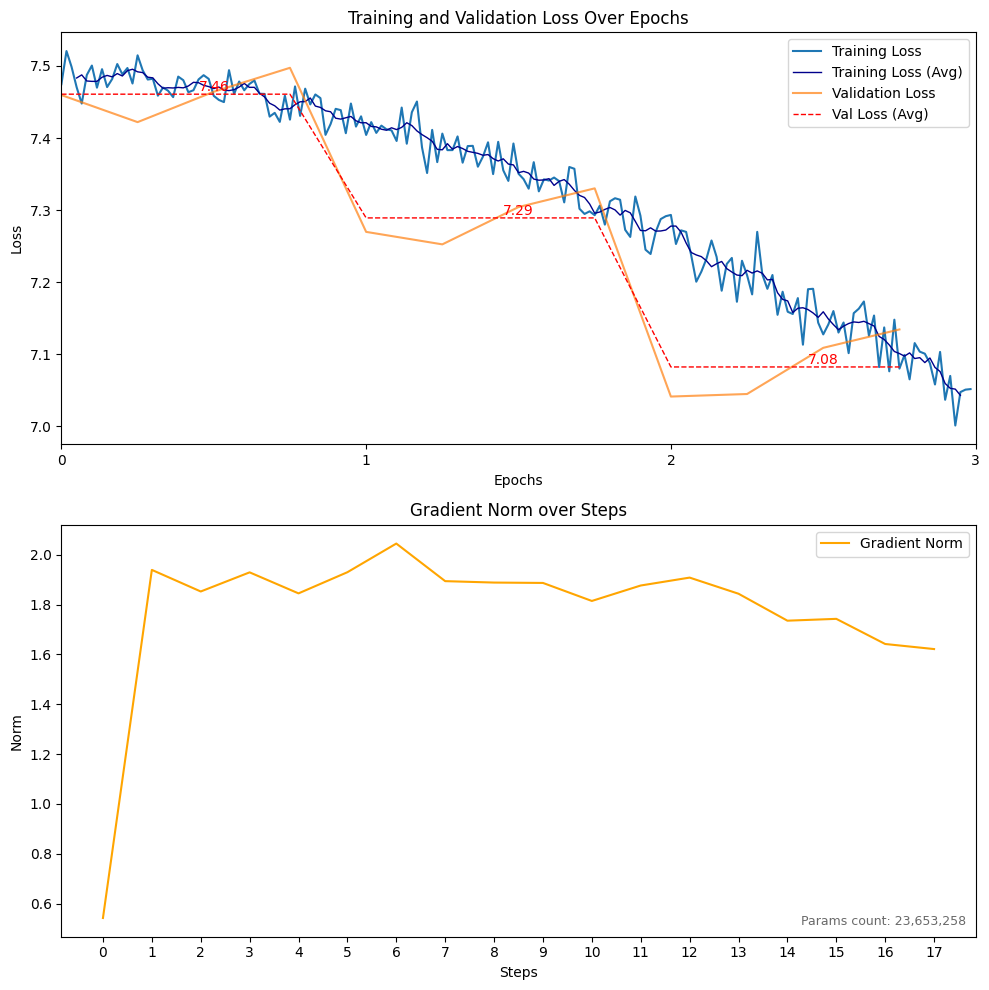

In [219]:
# launch the training process
if __name__ == "__main__":
    print(f"Dataset found at {DATA_PATH} Initializing training...")
    tokenizer_src, tokenizer_tgt = load_tokenizers(data_path=DATA_PATH) 
    train_model(tokenizer_src, tokenizer_tgt)

# Inference

In [220]:
from torchmetrics.text import BLEUScore
from tqdm import tqdm

In [221]:
def greedy_decode(model, src, src_mask, max_len, start_symbol):
    memory = model.encode(src, src_mask)
    # use the batch size from the source
    batch_size = src.size(0)
    ys = torch.zeros(batch_size, 1).fill_(start_symbol).type_as(src.data)
    
    for i in range(max_len - 1):
        out = model.decode(
            memory, src_mask, ys, subsequent_mask(ys.size(1)).type_as(src.data)
        )
        prob = model.generator(out[:, -1])
        _, next_word = torch.max(prob, dim=1)
        # next_word is (batch_size,) -> unsqueeze to (batch_size, 1) for concat
        ys = torch.cat(
            [ys, next_word.unsqueeze(1)], dim=1
        )
    return ys

In [222]:
def check_outputs(dataloader, model, tokenizer_src, tokenizer_tgt,
    n_examples=5, pad_idx=1, eos_string="</s>"):
    "Check the models outputs against the ground truth"

    results = [()] * n_examples
    valid_iter = iter(dataloader) 
    
    for idx in range(n_examples):
        print("\nExample %d ========\n" % idx)
        try:
            # Get the NEXT batch from the iterator
            b = next(valid_iter)
        except StopIteration:
            print('No more examples in test set.')
            break
            
        rb = Batch(b[0], b[1], pad_idx)
        
        src_text = tokenizer_src.decode(rb.src[0].tolist(), skip_special_tokens=True)
        tgt_text = tokenizer_tgt.decode(rb.tgt[0].tolist(), skip_special_tokens=True)

        print("Source Text (Input)        : " + src_text)
        print("Target Text (Ground Truth) : " + tgt_text)
        
        model_out = greedy_decode(model, rb.src, rb.src_mask, 72, 0)[0]
        model_txt = tokenizer_tgt.decode(model_out.tolist(), skip_special_tokens=True)
        
        print("Model Output               : " + model_txt)
        results[idx] = (rb, src_text, tgt_text, model_out, model_txt)
        
    return results

In [223]:
def calculate_bleu(model, dataloader, tokenizer_tgt, device=DEVICE):
    "Compute BLEU score, which measures n-gram overlaps"
    model.eval()
    metric = BLEUScore()
    
    preds, targets = [], []
    pad_idx = tokenizer_tgt.token_to_id("<pad>")
    start_symbol = tokenizer_tgt.token_to_id("<s>")
    
    with torch.no_grad():
        for b in tqdm(dataloader, desc="Computing BLEU"):
            src = b[0].to(device)  # b[0]: src, b[1]: tgt 
            src_mask = (src != pad_idx).unsqueeze(-2)
    
            model_out = greedy_decode(model, src, src_mask, max_len=72, start_symbol=start_symbol)
            preds.extend(tokenizer_tgt.decode_batch(model_out.cpu().tolist(), skip_special_tokens=True))     
            # Decode Ground Truth (b[1])
            ref_texts = tokenizer_tgt.decode_batch(b[1].tolist(), skip_special_tokens=True)
            targets.extend([[t] for t in ref_texts])

    score = metric(preds, targets)
    print(f"BLEU Score: {score.item():.4f}")

In [224]:
if __name__ == "__main__":
    
    tokenizer_src = Tokenizer.from_file("tokenizers/kaggle_tokenizer_src.json")
    tokenizer_tgt = Tokenizer.from_file("tokenizers/kaggle_tokenizer_tgt.json")
    
    model = make_model(tokenizer_src.get_vocab_size(), tokenizer_tgt.get_vocab_size(), stream_amount=4, N=6, feature_amount=512, d_ff=2048, h=8, dropout_rate=0.1)
    checkpoint_path = "checkpoints/checkpoint_02.pt"
    print(f"Loading {checkpoint_path}...")
    
    num_params = sum(p.numel() for p in model.parameters())
    print(f"Number of parameters: {num_params}")

    # Load the saved weights to the model
    state_dict = torch.load(checkpoint_path, map_location=torch.device(DEVICE))
    model.load_state_dict(state_dict)
    model.to(DEVICE)
    model.eval()

    _, valid_dataloader = create_dataloaders(
        tokenizer_src,
        tokenizer_tgt,
        batch_size=32)

    check_outputs(valid_dataloader, model, tokenizer_src, tokenizer_tgt)
    calculate_bleu(model, valid_dataloader, tokenizer_tgt)

Loading checkpoints/checkpoint_02.pt...
Number of parameters: 94795818


RuntimeError: Error(s) in loading state_dict for EncoderDecoder:
	Missing key(s) in state_dict: "encoder.layers.2.self_attn.sin", "encoder.layers.2.self_attn.cos", "encoder.layers.2.self_attn.linears.0.weight", "encoder.layers.2.self_attn.linears.1.weight", "encoder.layers.2.self_attn.linears.2.weight", "encoder.layers.2.self_attn.linears.3.weight", "encoder.layers.2.feed_forward.w_1.weight", "encoder.layers.2.feed_forward.w_1.bias", "encoder.layers.2.feed_forward.w_2.weight", "encoder.layers.2.feed_forward.w_2.bias", "encoder.layers.2.sublayer.0.alpha_pre", "encoder.layers.2.sublayer.0.alpha_post", "encoder.layers.2.sublayer.0.alpha_res", "encoder.layers.2.sublayer.0.phi_pre", "encoder.layers.2.sublayer.0.phi_post", "encoder.layers.2.sublayer.0.phi_res", "encoder.layers.2.sublayer.0.biais_pre", "encoder.layers.2.sublayer.0.biais_post", "encoder.layers.2.sublayer.0.biais_res", "encoder.layers.2.sublayer.0.norm.scale", "encoder.layers.2.sublayer.1.alpha_pre", "encoder.layers.2.sublayer.

# Deprecated

In [ ]:
class LayerNorm(nn.Module):
    "Offset average and scale by variance the hidden states."

    def __init__(self, feature_amount, eps=1e-6):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(feature_amount))
        self.offset = nn.Parameter(torch.zeros(feature_amount))
        self.eps = eps  # to not divide by zero

    def forward(self, x):
        # x: (B, L, S*D)
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.scale * (x - mean) / (std + self.eps) + self.offset

In [ ]:
class ResidualConnection(nn.Module):
    "A residual connection followed by a layer norm."

    def __init__(self, feature_amount, dropout_rate):
        super().__init__()
        self.norm = LayerNorm(feature_amount)
        self.dropout = nn.Dropout(dropout_rate) 
        # zeros randomly a part of the weights during training (not inference)

    def forward(self, x, sublayer):
        # x: (B, L, S, D)
        # sublayer: (B, L, S, d) -> (B, L, S, d)
        "Apply residual connection to any sublayer with the same size."
        return x + self.dropout(sublayer(self.norm(x)))

In [ ]:
class PositionalEncoding(nn.Module):
    """Implement the PE function, before we split tokens into streams. 
    We need this because of the dot product in the attention layers, which is permutation invariant."""

    def __init__(self, feature_amount, dropout_rate, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(dropout_rate)

        # compute the positional encodings once in log space.
        pe = torch.zeros(max_len, feature_amount)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, feature_amount, 2) * -(math.log(10000.0) / feature_amount))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (B, L, D)
        # output: (B, L, D)
        x = x + self.pe[:, :x.size(1)].requires_grad_(False)
        x = self.dropout(x)
        return x